# 🇮🇳 Suicide Rates in India — 2021
### Cause-wise Distribution Analysis
---
**Data Source:** NCRB — Accidental Deaths & Suicides in India 2021  
**Dataset:** Cause-wise_Distribution_2021.csv  
**Tools:** Python · Pandas · Matplotlib · Seaborn


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, glob, warnings
warnings.filterwarnings('ignore')
print("Libraries loaded ✅")

Libraries loaded ✅


## 📂 Load & Preview Dataset

In [43]:
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
FILE_PATH = csv_files[0]

df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip()
print(f"Loaded: {FILE_PATH} | Shape: {df.shape}")
df.head(10)

Loaded: /kaggle/input/datasets/anewsevile/suicide-rates-in-india2021/Cause-wise_Distribution_2021.csv | Shape: (31, 26)


,Sl.No,Cause,Below 18 years - Male,Below 18 years - Female,Below 18 years - Transgender,Below 18 years - Total,18 and Above-Below 30 years - Male,18 and Above-Below 30 years - Female,18 and Above-Below 30 years - Transgender,18 and Above-Below 30 years - Total,...,45 and Above-Below 60 years - Transgender,45 and Above-Below 60 years - Total,60 years & Above - Male,60 years & Above - Female,60 years & Above - Transgender,60 years & Above - Total,Total - Male,Total - Female,Total - Transgender,Total - Total
0,1,Bankruptcy or Indebtedness,16,10,0,26,1100,125,0,1225,...,0,1928,426,29,0,455,5879,482,0,6361
1,2,Marriage Related Issues (Total),68,126,0,194,1772,2631,1,4404,...,0,500,61,10,0,71,3833,4069,1,7903
2,2,2.1 Non Settlement of Marriage,14,42,0,56,867,644,0,1511,...,0,116,9,1,0,10,1616,1031,0,2647
3,2,2.2 Dowry Related Issues,1,22,0,23,120,1137,1,1258,...,0,17,6,1,0,7,220,1503,1,1724
4,2,2.3 Extra Marital Affairs,34,17,0,51,345,301,0,646,...,0,129,20,1,0,21,855,593,0,1448
5,2,2.4 Divorce,0,0,0,0,107,105,0,212,...,0,75,5,0,0,5,349,217,0,566
6,2,2.5 Others,19,45,0,64,333,444,0,777,...,0,163,21,7,0,28,793,725,0,1518
7,3,Failure in Examination,467,397,0,864,449,265,0,714,...,0,20,2,1,0,3,991,682,0,1673
8,4,Impotency/Infertility,0,13,0,13,43,102,0,145,...,0,60,9,4,0,13,185,222,0,407
9,5,Family Problems,1630,1603,0,3233,12345,6786,3,19134,...,0,9613,3208,939,0,4147,38634,15769,7,54410


## 🧹 Data Cleaning

In [44]:
main = df[~df['Cause'].str.contains(r'^\d+\.\d+', na=False)].copy()
main = main[main['Cause'] != 'Total'].copy()

for col in ['Total - Total', 'Total - Male', 'Total - Female']:
    main[col] = pd.to_numeric(main[col], errors='coerce')

main = main.dropna(subset=['Total - Total'])
main = main.sort_values('Total - Total', ascending=False).reset_index(drop=True)
print(f"Total causes: {len(main)}")
main[['Cause', 'Total - Male', 'Total - Female', 'Total - Total']].head()

Total causes: 20


,Cause,Total - Male,Total - Female,Total - Total
0,Family Problems,38634,15769,54410
1,Illness (Total),21014,9426,30446
2,Causes Not Known,11728,4243,15974
3,Other Causes,10726,4396,15129
4,Drug Abuse/Alcoholic Addiction,10284,275,10560


In [45]:
age_cols   = ['Below 18 years - Total', '18 and Above-Below 30 years - Total',
              '30 and Above-Below 45 years - Total', '45 and Above-Below 60 years - Total',
              '60 years & Above - Total']
age_labels = ['<18', '18-30', '30-45', '45-60', '60+']

total_row  = df[df['Cause'] == 'Total'].iloc[0]
age_vals   = [pd.to_numeric(total_row[c], errors='coerce') for c in age_cols]
total_male   = int(pd.to_numeric(total_row['Total - Male'],   errors='coerce'))
total_female = int(pd.to_numeric(total_row['Total - Female'], errors='coerce'))
print("Done ✅")

Done ✅


## 📊 Visualizations

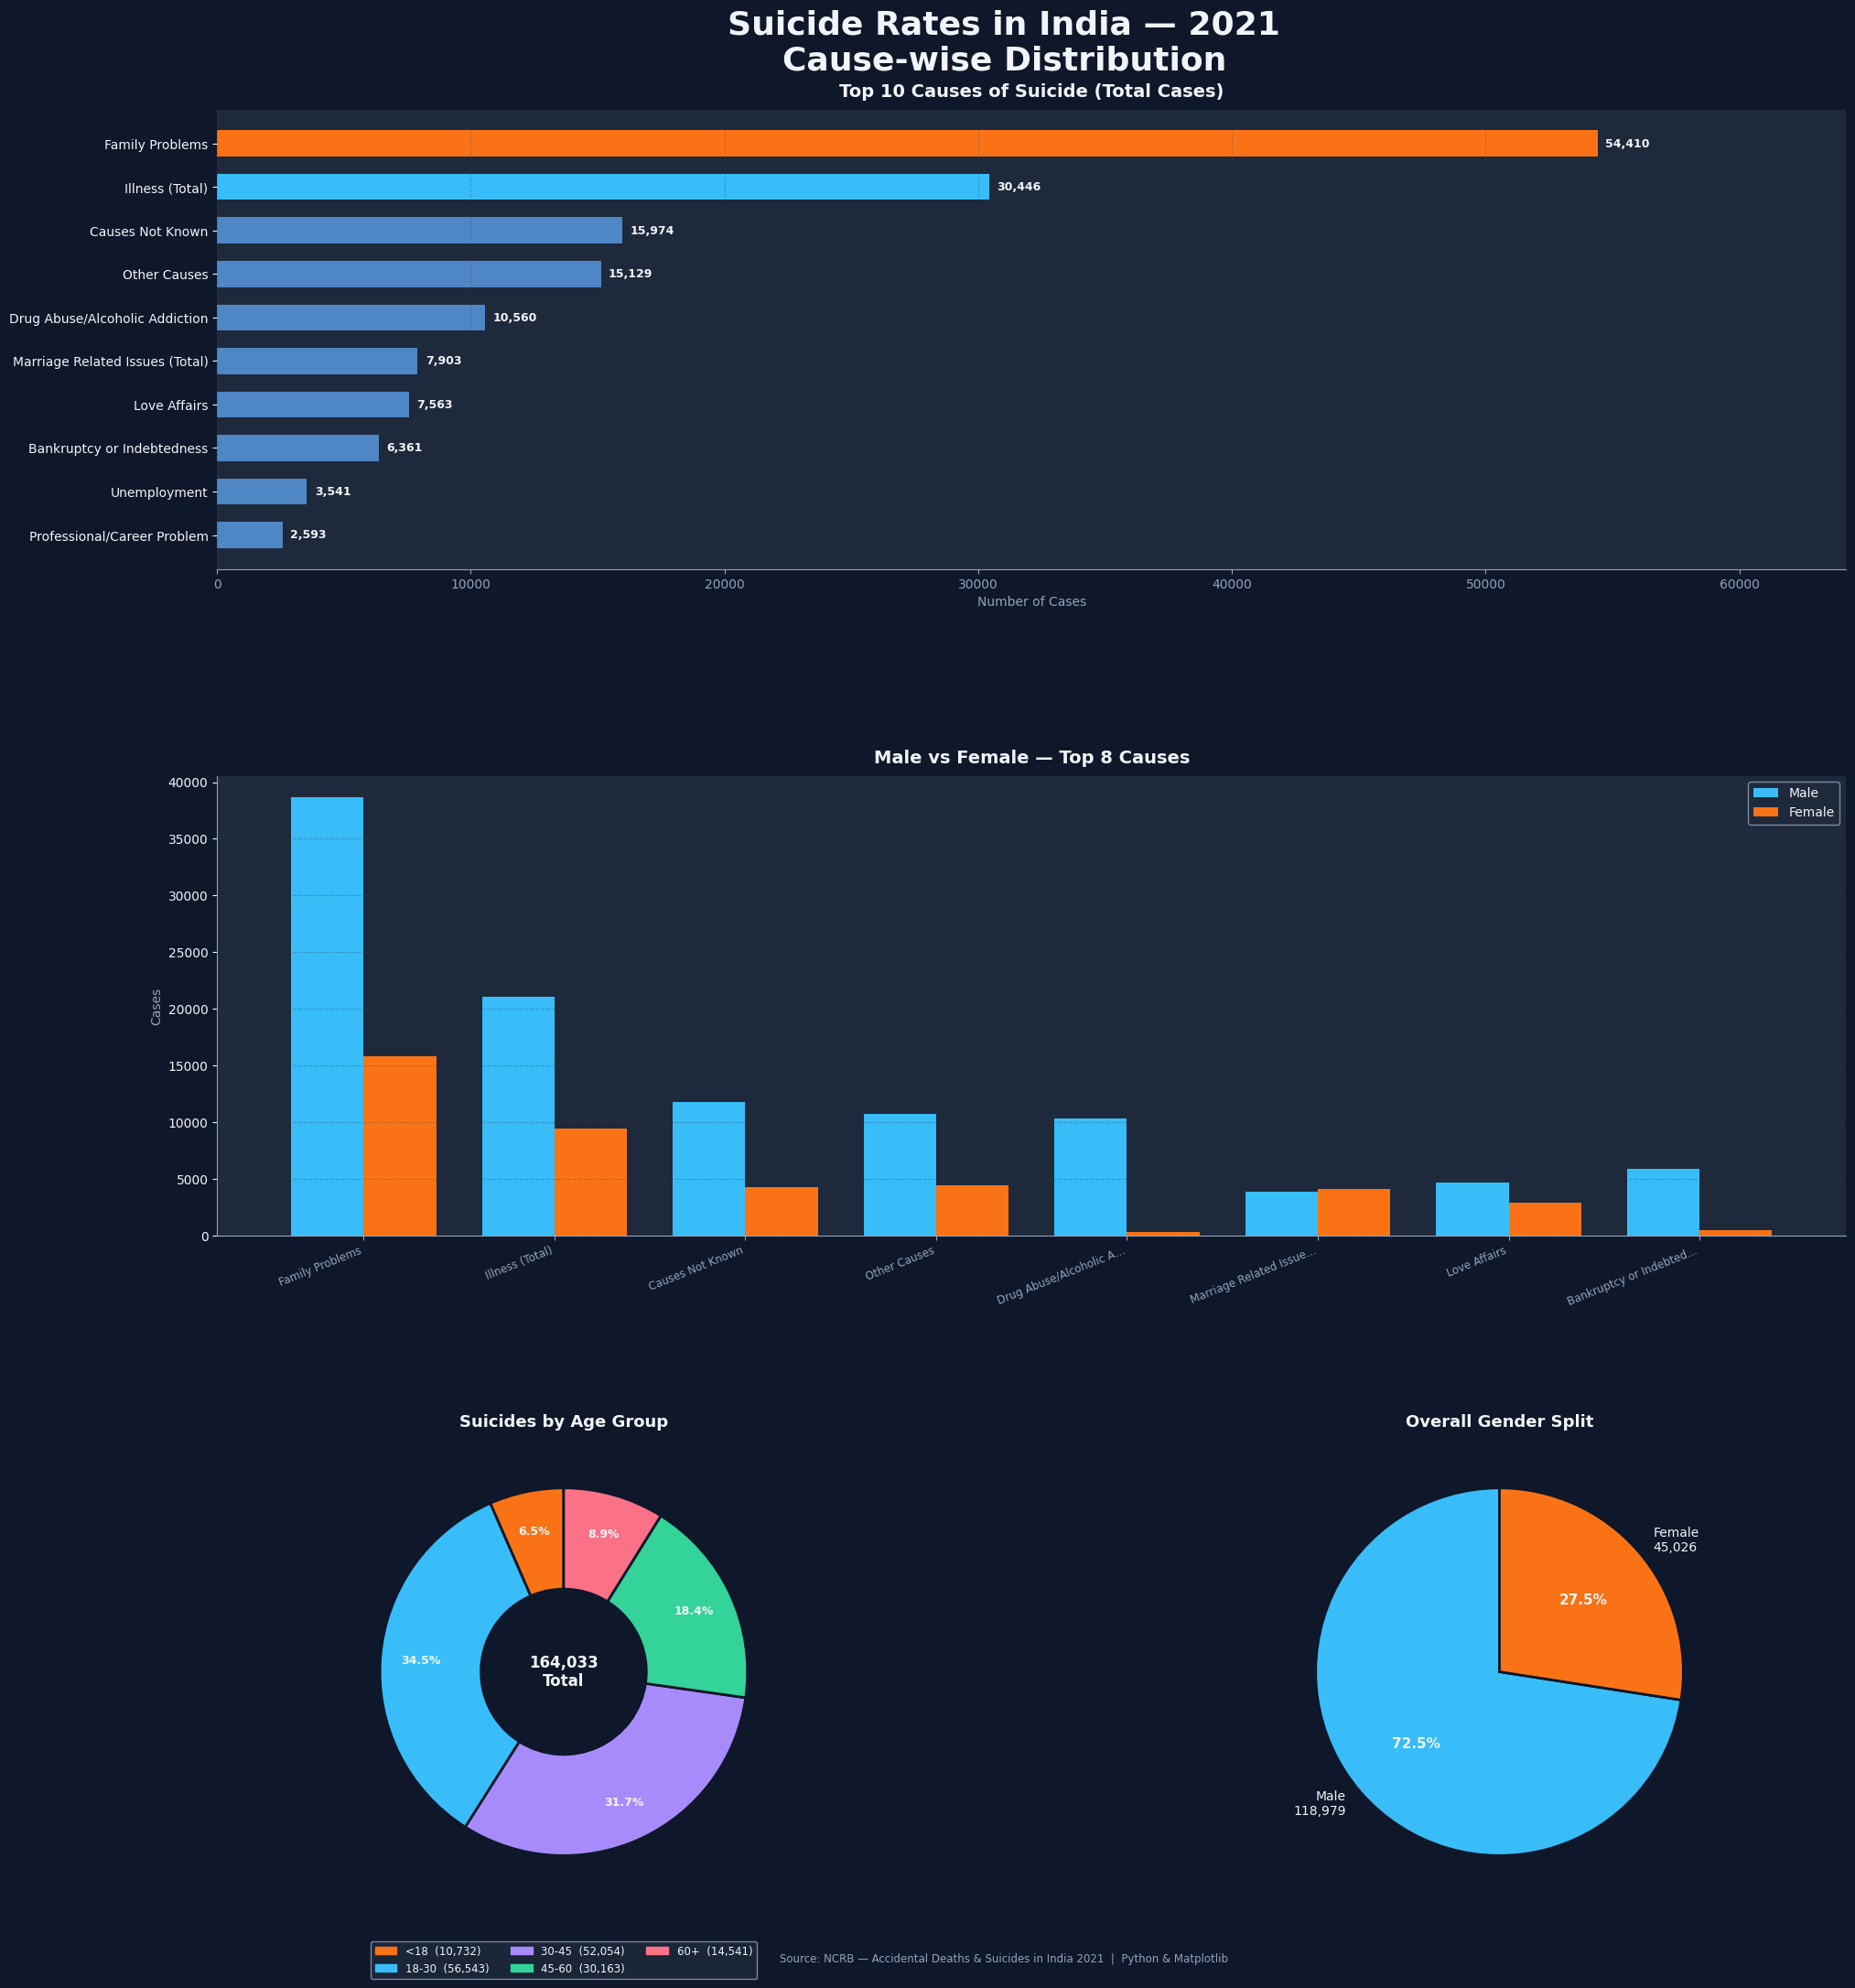

✅ Done!


In [46]:
DARK  = '#0f172a'; CARD  = '#1e293b'; ACC1  = '#f97316'
ACC2  = '#38bdf8'; ACC3  = '#a78bfa'; ACC4  = '#34d399'
TEXT  = '#f1f5f9'; MUTED = '#94a3b8'

plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor': CARD,
    'axes.edgecolor': MUTED,  'text.color': TEXT,
    'axes.labelcolor': TEXT,  'xtick.color': MUTED,
    'ytick.color': TEXT,      'grid.color': '#334155',
    'grid.linestyle': '--',   'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
})

fig = plt.figure(figsize=(20, 22), facecolor=DARK)
fig.suptitle('Suicide Rates in India — 2021\nCause-wise Distribution',
             fontsize=26, fontweight='bold', color=TEXT, y=0.98)

gs = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35,
                      left=0.07, right=0.96, top=0.93, bottom=0.04)

# Chart 1: Top 10 Causes
ax1 = fig.add_subplot(gs[0, :])
top10  = main.head(10)
colors = [ACC1 if i == 0 else ACC2 if i == 1 else '#4f86c6' for i in range(len(top10))]
bars = ax1.barh(top10['Cause'][::-1], top10['Total - Total'][::-1],
                color=colors[::-1], edgecolor='none', height=0.6)
for bar, val in zip(bars, top10['Total - Total'][::-1]):
    ax1.text(val + 300, bar.get_y() + bar.get_height()/2,
             f'{int(val):,}', va='center', fontsize=9, color=TEXT, fontweight='bold')
ax1.set_title('Top 10 Causes of Suicide (Total Cases)', fontsize=14, color=TEXT, pad=10, fontweight='bold')
ax1.set_xlabel('Number of Cases', fontsize=10, color=MUTED)
ax1.set_xlim(0, top10['Total - Total'].max() * 1.18)
ax1.grid(axis='x', alpha=0.3)
sns.despine(ax=ax1, left=True, bottom=False)

# Chart 2: Gender Split
ax2 = fig.add_subplot(gs[1, :])
top8 = main.head(8)
x, w = range(len(top8)), 0.38
ax2.bar([i - w/2 for i in x], top8['Total - Male'],   width=w, color=ACC2, label='Male',   edgecolor='none')
ax2.bar([i + w/2 for i in x], top8['Total - Female'], width=w, color=ACC1, label='Female', edgecolor='none')
short = [c[:22]+'…' if len(c) > 22 else c for c in top8['Cause']]
ax2.set_xticks(list(x))
ax2.set_xticklabels(short, rotation=22, ha='right', fontsize=8.5)
ax2.set_title('Male vs Female — Top 8 Causes', fontsize=14, color=TEXT, pad=10, fontweight='bold')
ax2.set_ylabel('Cases', fontsize=10, color=MUTED)
ax2.legend(fontsize=10, facecolor=CARD, edgecolor=MUTED, labelcolor=TEXT, loc='upper right')
ax2.grid(axis='y', alpha=0.3)
sns.despine(ax=ax2, left=False, bottom=False)

# Chart 3: Age Donut
ax3 = fig.add_subplot(gs[2, 0])
donut_colors = [ACC1, ACC2, ACC3, ACC4, '#fb7185']
wedges, texts, autotexts = ax3.pie(
    age_vals, autopct='%1.1f%%', colors=donut_colors, startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': DARK, 'linewidth': 2},
    pctdistance=0.78, textprops={'color': TEXT, 'fontsize': 9})
for at in autotexts:
    at.set_fontweight('bold')
legend_patches = [mpatches.Patch(color=donut_colors[i], label=f'{age_labels[i]}  ({int(age_vals[i]):,})')
                  for i in range(len(age_labels))]
ax3.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.18),
           ncol=3, fontsize=8.5, facecolor=CARD, edgecolor=MUTED, labelcolor=TEXT)
ax3.text(0, 0, f'{int(sum(age_vals)):,}\nTotal', ha='center', va='center',
         fontsize=12, fontweight='bold', color=TEXT)
ax3.set_title('Suicides by Age Group', fontsize=13, color=TEXT, pad=12, fontweight='bold')

# Chart 4: Gender Pie
ax4 = fig.add_subplot(gs[2, 1])
gender_labels = [f'Male\n{total_male:,}', f'Female\n{total_female:,}']
wedges2, _, autotexts2 = ax4.pie(
    [total_male, total_female], labels=gender_labels, autopct='%1.1f%%',
    colors=[ACC2, ACC1], startangle=90,
    wedgeprops={'edgecolor': DARK, 'linewidth': 2},
    pctdistance=0.6, textprops={'color': TEXT, 'fontsize': 10})
for at in autotexts2:
    at.set_fontweight('bold')
    at.set_fontsize(11)
ax4.set_title('Overall Gender Split', fontsize=13, color=TEXT, pad=12, fontweight='bold')

fig.text(0.5, 0.01,
         'Source: NCRB — Accidental Deaths & Suicides in India 2021  |  Python & Matplotlib',
         ha='center', fontsize=8.5, color=MUTED)

plt.savefig('suicide_india_2021.png', dpi=180, bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Done!")

## 💡 Key Insights

1. **Family Problems** is the leading cause of suicide in India (2021) with over **54,000 cases** — nearly 3× the second-highest cause.
2. **Males account for ~73%** of all suicide deaths, significantly higher than females.
3. The **30–45 age group** is the most vulnerable, contributing the largest share across all causes.
4. **Mental Illness** (under Illness category) and **Drug/Alcohol Addiction** are major contributors, highlighting a public health crisis.
5. **Love Affairs** and **Unemployment** disproportionately affect the **18–30 age group**.
6. **Failure in Examinations** spikes in the under-18 group — a concern for student mental health.

---
*Data: NCRB Report 2021 | Visualization: Python (Matplotlib, Seaborn, Pandas)*
